<a href="https://colab.research.google.com/github/Dana-El/CCI-HW1/blob/main/Assignment_Clinical_Intake_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 2 Assignment: The Complete Clinical Intake Pipeline
## CCI Prompt Engineering & Clinical AI Development

**Due:** Before Session 3  
**Estimated effort:** 3-5 hours  
**Submission:** Push to your `cci-course-notebooks` GitHub repo under `assignments/session-2/`

### Clinical Scenario
> KHCC's outpatient oncology clinic receives 30-50 new patient intake forms daily. Each form contains demographics, initial lab results, current medications, and a brief clinical note. Currently, a data entry clerk manually reviews each form, flags abnormal labs, checks for drug interactions, and prepares a summary report for the oncologist. This takes 2-3 hours per day. You have been asked to build a Python notebook that automates this workflow.

### Grading
| Part | Weight | Description |
|------|--------|-------------|
| Part 1 | 30% | Build the Intake Data Model |
| Part 2 | 30% | Merge, Analyze, and Export |
| Part 3 | 20% | Analysis & Critical Thinking |
| Part 4 | 20% | Stretch Challenge |

### Anti-Shortcut Rules
- You MUST use 15+ unique patients with varied, realistic data
- Your Part 3 analysis must reference YOUR specific implementation
- All three CSV files must be produced by running the notebook top-to-bottom
- Push to GitHub with at least 3 separate commits with descriptive messages

---
## Section 1: Package Installations

In [60]:
# === SECTION 1: PACKAGE INSTALLATIONS ===
# TODO: Install any packages you need (pandas is pre-installed in Colab)


---
## Section 2: Imports

In [61]:
# === SECTION 2: IMPORTS ===
# TODO: Import the modules you will need
# At minimum: pandas, csv, datetime
import pandas as pd
import csv
from datetime import datetime
import random


---
## Section 3: Configuration

In [62]:
# === SECTION 3: CONFIGURATION ===
# TODO: Define clinical thresholds
HGB_LOW = 11.0
HGB_CRITICAL = 7.0
WBC_HIGH = 11.0
WBC_LOW = 4.0
PLATELETS_LOW = 150
CREATININE_HIGH = 1.2

# TODO: Define output file names for the 3 CSVs
ALL_PATIENTS_CSV = 'all_patients.csv'
HIGH_RISK_PATIENTS_CSV = 'high_risk_patients.csv'
DRUG_INTERACTION_ALERTS_CSV = 'drug_interaction_alerts.csv'


---
## Section 4: Prompts

In [63]:
# === SECTION 4: PROMPTS ===
# TODO: Define any prompt templates for future LLM integration
# Example: A prompt to summarize the daily intake report
DAILY_SUMMARY_PROMPT = """
Role: You are a clinical AI assistant at KHCC's outpatient oncology clinic.
Objective: Generate a concise daily patient intake summary report based on the provided data.
Limitations:
- Do not include any information not explicitly derived from the provided data.
- Do not speculate or provide medical advice.
- Keep the summary concise and to the point.
Expectations:
- Start with overall statistics: Total patients processed, Number of high-risk patients, Number of drug interaction alerts.
- List the MRN and name of all high-risk patients, along with their primary alerts (e.g., critical lab values, multiple abnormalities).
- List all identified drug interactions, specifying the patient MRN, the interacting drugs, and the description of the interaction.
- Clearly highlight any urgent findings, such as critical lab values or high-severity drug interactions.

Data for summary:
Total patients processed: {total_patients}
Number of high-risk patients: {high_risk_count}
Number of drug interaction alerts: {interaction_count}

High-Risk Patient Details:
{high_risk_details}

Drug Interaction Details:
{interaction_details}
"""

---
## Section 5: Functions

### Part 1 -- PatientIntake Class (30%)

Define a `PatientIntake` class with:
- **Attributes:** name, mrn, age, gender, diagnosis, hemoglobin, wbc, platelets, creatinine, medications (list of strings), clinical_note (string)
- **Methods:**
  - `get_lab_alerts()` -- returns a list of alert strings for abnormal lab values
  - `is_high_risk()` -- returns True if multiple criteria are met (e.g., low HGB + abnormal WBC + on chemo)
  - `summary()` -- returns a formatted string with all patient info
  - `to_dict()` -- returns a dictionary for CSV export

In [64]:
# === SECTION 5: FUNCTIONS ===

class PatientIntake:
    """Represents a patient intake form with demographics, labs, medications, and clinical note."""

    def __init__(self, name, mrn, age, gender, diagnosis, hemoglobin, wbc,
                 platelets, creatinine, medications=None, clinical_note=""):
        # TODO: Store all parameters as instance variables using self
        self.name = name
        self.mrn = mrn
        self.age = age
        self.gender = gender
        self.diagnosis = diagnosis
        self.hemoglobin = hemoglobin
        self.wbc = wbc
        self.platelets = platelets
        self.creatinine = creatinine
        self.medications = medications if medications is not None else []
        self.clinical_note = clinical_note

    def get_lab_alerts(self):
        """Check all lab values against thresholds and return a list of alert strings."""
        alerts = []
        # TODO: Check hemoglobin (low, critical)
        if self.hemoglobin < HGB_CRITICAL:
            alerts.append(f"CRITICAL Hemoglobin: {self.hemoglobin} g/dL")
        elif self.hemoglobin < HGB_LOW:
            alerts.append(f"LOW Hemoglobin: {self.hemoglobin} g/dL")

        # TODO: Check WBC (high, low)
        if self.wbc > WBC_HIGH:
            alerts.append(f"HIGH WBC: {self.wbc} K/uL")
        elif self.wbc < WBC_LOW:
            alerts.append(f"LOW WBC: {self.wbc} K/uL")

        # TODO: Check platelets (low)
        if self.platelets < PLATELETS_LOW:
            alerts.append(f"LOW Platelets: {self.platelets} K/uL")

        # TODO: Check creatinine (high)
        if self.creatinine > CREATININE_HIGH:
            alerts.append(f"HIGH Creatinine: {self.creatinine} mg/dL")
        return alerts

    def is_high_risk(self):
        """Returns True if patient meets multiple risk criteria."""
        # TODO: Define your high-risk criteria
        # Example: 2+ abnormal labs, or critical hemoglobin, or neutropenic + on chemo
        alerts = self.get_lab_alerts()
        # Criteria 1: Critical hemoglobin
        if any("CRITICAL Hemoglobin" in alert for alert in alerts):
            return True
        # Criteria 2: 2 or more abnormal labs
        if len(alerts) >= 2:
            return True
        # Criteria 3: Specific diagnosis with very low WBC (potential neutropenia)
        if "Leukemia" in self.diagnosis and self.wbc < 1.0: # Very low WBC often indicates severe neutropenia
            return True
        # Criteria 4: On a chemotherapy drug with abnormal labs
        chemo_drugs = ["Cisplatin", "Paclitaxel", "Doxorubicin", "Fluorouracil"]
        if any(drug in self.medications for drug in chemo_drugs) and len(alerts) >= 1:
            return True
        return False

    def summary(self):
        """Returns a formatted summary string."""
        # TODO: Return a multi-line string with all patient details
        s = f"MRN: {self.mrn}\nName: {self.name}, Age: {self.age}, Gender: {self.gender}\n"
        s += f"Diagnosis: {self.diagnosis}\n"
        s += f"Labs - HGB: {self.hemoglobin}, WBC: {self.wbc}, Platelets: {self.platelets}, Creatinine: {self.creatinine}\n"
        s += f"Medications: {', '.join(self.medications) if self.medications else 'None'}\n"
        s += f"Clinical Note: {self.clinical_note}"
        alerts = self.get_lab_alerts()
        if alerts:
            s += f"\nAlerts: {'; '.join(alerts)}"
        if self.is_high_risk():
            s += f"\n*** HIGH RISK PATIENT ***"
        return s

    def to_dict(self):
        """Returns a dictionary representation for DataFrame/CSV conversion."""
        # TODO: Return a dict with all attributes
        # Include: name, mrn, age, gender, diagnosis, hemoglobin, wbc,
        #          platelets, creatinine, medications (as comma-separated string),
        #          clinical_note, is_high_risk (bool), alert_count (int)
        alerts = self.get_lab_alerts()
        return {
            'name': self.name,
            'mrn': self.mrn,
            'age': self.age,
            'gender': self.gender,
            'diagnosis': self.diagnosis,
            'hemoglobin': self.hemoglobin,
            'wbc': self.wbc,
            'platelets': self.platelets,
            'creatinine': self.creatinine,
            'medications': ', '.join(self.medications) if self.medications else '',
            'clinical_note': self.clinical_note,
            'is_high_risk': self.is_high_risk(),
            'alert_count': len(alerts)
        }


---
## Section 6: Main Code

### Create 15+ Patient Intake Records
Use varied, realistic oncology data. Include:
- Some patients with all normal values
- Some with critical values
- Some with multiple abnormalities
- Different diagnoses (at least 4 different cancer types)
- Both male and female patients
- Different medications

In [65]:
# === SECTION 6: MAIN CODE ===

# TODO: Create at least 15 PatientIntake objects
# Use varied, realistic KHCC oncology data
# Example:
# p1 = PatientIntake("Ahmad", "P-1001", 58, "M", "Lung Cancer",
#                    hemoglobin=9.1, wbc=6.2, platelets=180, creatinine=1.1,
#                    medications=["Cisplatin", "Pemetrexed"],
#                    clinical_note="New diagnosis, stage IIIA NSCLC")

def generate_patient_data(num_patients=15):
    patient_list = []
    diagnoses = ["Lung Cancer", "Breast Cancer", "Colorectal Cancer", "Leukemia", "Lymphoma", "Ovarian Cancer"]
    medication_options = [
        [], # No meds
        ["Cisplatin", "Metformin"], # Interaction risk
        ["Warfarin", "Ibuprofen"], # Interaction risk
        ["Paclitaxel", "Dexamethasone"],
        ["Doxorubicin"],
        ["Fluorouracil", "Leucovorin"],
        ["Aspirin"],
        ["Morphine"],
        ["Omeprazole"],
        ["Tamoxifen"],
        ["Herceptin"],
        ["Avastin"],
        ["Prednisone"]
    ]

    for i in range(num_patients):
        name = f"Patient {i+1}"
        mrn = f"P-{1000 + i}"
        age = random.randint(30, 80)
        gender = random.choice(["M", "F"])
        diagnosis = random.choice(diagnoses)

        # Generate lab values with some variation and potential for abnormalities
        hemoglobin = round(random.uniform(6.0, 16.0), 1) # Normal: 12-16, Low: <12, Critical: <7
        wbc = round(random.uniform(1.0, 15.0), 1) # Normal: 4.5-11, High: >11, Low: <4.5
        platelets = random.randint(50, 400) # Normal: 150-450, Low: <150
        creatinine = round(random.uniform(0.5, 2.0), 1) # Normal: 0.6-1.2, High: >1.2

        medications = random.choice(medication_options)
        clinical_note = f"Initial intake for {diagnosis} patient. Some fatigue reported."

        # Introduce specific scenarios for high-risk and critical values
        if i % 3 == 0: # Every 3rd patient has some critical lab
            if random.random() < 0.5: # Critical HGB
                hemoglobin = round(random.uniform(5.0, 6.9), 1)
                clinical_note += " Critical hemoglobin detected."
            else: # Very low WBC (neutropenia)
                wbc = round(random.uniform(0.5, 0.9), 1)
                diagnosis = "Leukemia" # Ensure diagnosis for neutropenia check
                medications.append("Chemotherapy_DrugX")
                clinical_note += " Severe neutropenia suspected."
        elif i % 5 == 0: # Every 5th patient has multiple abnormalities
            hemoglobin = round(random.uniform(8.0, 10.9), 1)
            wbc = round(random.uniform(2.0, 3.9), 1)
            platelets = random.randint(70, 149)
            clinical_note += " Multiple lab abnormalities."
        elif i % 7 == 0: # Every 7th patient has a drug interaction candidate
            medications = ["Warfarin", "Ibuprofen"] if random.random() < 0.5 else ["Cisplatin", "Metformin"]
            clinical_note += " Potential drug interaction identified."

        patient = PatientIntake(name, mrn, age, gender, diagnosis, hemoglobin, wbc,
                                platelets, creatinine, medications, clinical_note)
        patient_list.append(patient)
    return patient_list

patients = generate_patient_data(num_patients=20) # Generating 20 patients to ensure 15+ and variety

print(f"Total patients: {len(patients)}")


Total patients: 20


In [66]:
# Print summaries and alerts for all patients
for p in patients:
    print(p.summary())
    alerts = p.get_lab_alerts()
    if alerts:
        print(f"  Alerts: {', '.join(alerts)}")
    if p.is_high_risk():
        print("  *** HIGH RISK ***")
    print()


MRN: P-1000
Name: Patient 1, Age: 38, Gender: F
Diagnosis: Breast Cancer
Labs - HGB: 5.1, WBC: 11.8, Platelets: 88, Creatinine: 1.8
Medications: Doxorubicin
Clinical Note: Initial intake for Breast Cancer patient. Some fatigue reported. Critical hemoglobin detected.
Alerts: CRITICAL Hemoglobin: 5.1 g/dL; HIGH WBC: 11.8 K/uL; LOW Platelets: 88 K/uL; HIGH Creatinine: 1.8 mg/dL
*** HIGH RISK PATIENT ***
  Alerts: CRITICAL Hemoglobin: 5.1 g/dL, HIGH WBC: 11.8 K/uL, LOW Platelets: 88 K/uL, HIGH Creatinine: 1.8 mg/dL
  *** HIGH RISK ***

MRN: P-1001
Name: Patient 2, Age: 46, Gender: F
Diagnosis: Lymphoma
Labs - HGB: 12.4, WBC: 6.3, Platelets: 170, Creatinine: 0.9
Medications: Doxorubicin
Clinical Note: Initial intake for Lymphoma patient. Some fatigue reported.

MRN: P-1002
Name: Patient 3, Age: 34, Gender: F
Diagnosis: Leukemia
Labs - HGB: 10.0, WBC: 10.7, Platelets: 154, Creatinine: 0.6
Medications: Herceptin, Chemotherapy_DrugX
Clinical Note: Initial intake for Leukemia patient. Some fati

---
### Part 2 -- Merge, Analyze, and Export (30%)

#### Step A: Convert patients to DataFrame

In [67]:
# Step A: Convert to DataFrame
# TODO: Use list comprehension to call to_dict() on each patient
# Then create a DataFrame from the list of dicts
import pandas as pd

df = pd.DataFrame([p.to_dict() for p in patients])  # TODO: Create DataFrame
print(df.head())
print(f"\nShape: {df.shape}")


        name     mrn  age gender          diagnosis  hemoglobin   wbc  \
0  Patient 1  P-1000   38      F      Breast Cancer         5.1  11.8   
1  Patient 2  P-1001   46      F           Lymphoma        12.4   6.3   
2  Patient 3  P-1002   34      F           Leukemia        10.0  10.7   
3  Patient 4  P-1003   55      M  Colorectal Cancer         5.3   3.0   
4  Patient 5  P-1004   55      M        Lung Cancer         7.4  11.4   

   platelets  creatinine                    medications  \
0         88         1.8                    Doxorubicin   
1        170         0.9                    Doxorubicin   
2        154         0.6  Herceptin, Chemotherapy_DrugX   
3        319         2.0                    Doxorubicin   
4        147         1.1                    Doxorubicin   

                                       clinical_note  is_high_risk  \
0  Initial intake for Breast Cancer patient. Some...          True   
1  Initial intake for Lymphoma patient. Some fati...         False

#### Step B: Create Drug Interaction Table

In [68]:
# Step B: Drug interaction table
# TODO: Create a DataFrame with at least 10 drug pairs that interact
# Columns: drug1, drug2, interaction_severity, description
# Example interactions:
# Cisplatin + Metformin -> Nephrotoxicity risk
# Warfarin + Ibuprofen -> Bleeding risk

interactions = pd.DataFrame([
    # TODO: Add at least 10 drug interaction pairs
    {"drug1": "Warfarin", "drug2": "Ibuprofen", "interaction_severity": "High", "description": "Increased risk of bleeding"},
    {"drug1": "Cisplatin", "drug2": "Metformin", "interaction_severity": "Medium", "description": "Increased risk of nephrotoxicity"},
    {"drug1": "Doxorubicin", "drug2": "Trastuzumab", "interaction_severity": "High", "description": "Increased cardiotoxicity"},
    {"drug1": "Methotrexate", "drug2": "NSAIDs", "interaction_severity": "High", "description": "Increased methotrexate toxicity"},
    {"drug1": "Tamoxifen", "drug2": "Paroxetine", "interaction_severity": "Medium", "description": "Decreased tamoxifen efficacy"},
    {"drug1": "Prednisone", "drug2": "Furosemide", "interaction_severity": "Medium", "description": "Increased risk of hypokalemia"},
    {"drug1": "Allopurinol", "drug2": "Azathioprine", "interaction_severity": "High", "description": "Increased myelosuppression"},
    {"drug1": "Rituximab", "drug2": "ACE Inhibitors", "interaction_severity": "Low", "description": "Hypotension risk"},
    {"drug1": "Cyclophosphamide", "drug2": "Digoxin", "interaction_severity": "Low", "description": "Altered digoxin levels"},
    {"drug1": "Levothyroxine", "drug2": "Iron Supplements", "interaction_severity": "Medium", "description": "Decreased levothyroxine absorption"},
    {"drug1": "Aspirin", "drug2": "Warfarin", "interaction_severity": "High", "description": "Increased risk of bleeding"}
])

print(interactions)


               drug1             drug2 interaction_severity  \
0           Warfarin         Ibuprofen                 High   
1          Cisplatin         Metformin               Medium   
2        Doxorubicin       Trastuzumab                 High   
3       Methotrexate            NSAIDs                 High   
4          Tamoxifen        Paroxetine               Medium   
5         Prednisone        Furosemide               Medium   
6        Allopurinol      Azathioprine                 High   
7          Rituximab    ACE Inhibitors                  Low   
8   Cyclophosphamide           Digoxin                  Low   
9      Levothyroxine  Iron Supplements               Medium   
10           Aspirin          Warfarin                 High   

                           description  
0           Increased risk of bleeding  
1     Increased risk of nephrotoxicity  
2             Increased cardiotoxicity  
3      Increased methotrexate toxicity  
4         Decreased tamoxifen efficacy

#### Step C: Check for Drug Interactions

In [69]:
# Step C: Match patient medications against interaction table
# TODO: For each patient, check if any of their medications appear in
# the drug interaction table (as drug1 or drug2)
# Build a list of interaction alerts

drug_interaction_alerts = []
for index, patient_row in df.iterrows():
    patient_meds = [m.strip() for m in patient_row['medications'].split(',') if m.strip()]
    if not patient_meds: # Skip if no medications
        continue

    for med1 in patient_meds:
        for med2 in patient_meds:
            if med1 == med2: # Don't check drug against itself
                continue

            # Check for interaction in either order (drug1, drug2) or (drug2, drug1)
            interaction_found = interactions[
                ((interactions['drug1'] == med1) & (interactions['drug2'] == med2)) |
                ((interactions['drug1'] == med2) & (interactions['drug2'] == med1))
            ]

            if not interaction_found.empty:
                for _, interaction_row in interaction_found.iterrows():
                    alert_description = f"MRN: {patient_row['mrn']}, Name: {patient_row['name']} - Interaction between {med1} and {med2}. Severity: {interaction_row['interaction_severity']}. Description: {interaction_row['description']}"
                    drug_interaction_alerts.append({
                        'mrn': patient_row['mrn'],
                        'name': patient_row['name'],
                        'drug1': med1,
                        'drug2': med2,
                        'interaction_severity': interaction_row['interaction_severity'],
                        'description': interaction_row['description']
                    })

if drug_interaction_alerts:
    drug_interaction_df = pd.DataFrame(drug_interaction_alerts)
    print("Drug Interaction Alerts Found:")
    print(drug_interaction_df)
else:
    print("No significant drug interactions found.")



Drug Interaction Alerts Found:
      mrn        name      drug1      drug2 interaction_severity  \
0  P-1007   Patient 8  Cisplatin  Metformin               Medium   
1  P-1007   Patient 8  Metformin  Cisplatin               Medium   
2  P-1009  Patient 10   Warfarin  Ibuprofen                 High   
3  P-1009  Patient 10  Ibuprofen   Warfarin                 High   
4  P-1013  Patient 14  Cisplatin  Metformin               Medium   
5  P-1013  Patient 14  Metformin  Cisplatin               Medium   
6  P-1014  Patient 15   Warfarin  Ibuprofen                 High   
7  P-1014  Patient 15  Ibuprofen   Warfarin                 High   

                        description  
0  Increased risk of nephrotoxicity  
1  Increased risk of nephrotoxicity  
2        Increased risk of bleeding  
3        Increased risk of bleeding  
4  Increased risk of nephrotoxicity  
5  Increased risk of nephrotoxicity  
6        Increased risk of bleeding  
7        Increased risk of bleeding  


#### Step D: Group Analysis

In [70]:
# Step D: Group by diagnosis and calculate summary statistics
# TODO: Use df.groupby('diagnosis') to calculate mean, min, max
# for hemoglobin, wbc, platelets, creatinine

print("Summary statistics by diagnosis:")
# TODO: Print the groupby results
summary_stats = df.groupby('diagnosis')[['hemoglobin', 'wbc', 'platelets', 'creatinine']].agg(['mean', 'min', 'max'])
print(summary_stats)


Summary statistics by diagnosis:
                  hemoglobin                   wbc              platelets  \
                        mean  min   max       mean  min   max        mean   
diagnosis                                                                   
Breast Cancer       7.900000  5.1  10.7   7.550000  3.3  11.8   84.500000   
Colorectal Cancer   8.150000  5.3  11.0   8.800000  3.0  14.6  328.000000   
Leukemia            8.675000  7.9  10.0   3.450000  0.5  10.7  244.750000   
Lung Cancer         9.566667  7.4  13.4  10.800000  8.9  12.1  211.000000   
Lymphoma            8.583333  5.7  12.4   7.100000  1.7  13.7  204.000000   
Ovarian Cancer     10.000000  6.0  15.0   8.666667  3.6  12.7  211.666667   

                            creatinine            
                   min  max       mean  min  max  
diagnosis                                         
Breast Cancer       81   88   1.900000  1.8  2.0  
Colorectal Cancer  319  337   1.650000  1.3  2.0  
Leukemia          

---
## Section 7: Build CSV

Export three CSV files:
1. `all_patients.csv` -- all 15+ patients
2. `high_risk_patients.csv` -- only high-risk patients
3. `drug_interaction_alerts.csv` -- drug interaction findings

In [71]:
# === SECTION 7: BUILD CSV ===

# TODO: Export CSV 1 - All patients
df.to_csv(ALL_PATIENTS_CSV, index=False)
print(f"Exported all patient data to {ALL_PATIENTS_CSV}")

# TODO: Export CSV 2 - High-risk patients only
high_risk_df = df[df['is_high_risk'] == True]
high_risk_df.to_csv(HIGH_RISK_PATIENTS_CSV, index=False)
print(f"Exported high-risk patient data to {HIGH_RISK_PATIENTS_CSV}")

# TODO: Export CSV 3 - Drug interaction alerts
if 'drug_interaction_df' in locals() and not drug_interaction_df.empty:
    drug_interaction_df.to_csv(DRUG_INTERACTION_ALERTS_CSV, index=False)
    print(f"Exported drug interaction alerts to {DRUG_INTERACTION_ALERTS_CSV}")
else:
    print("No drug interaction alerts to export.")

# TODO: Print confirmation messages for each file


Exported all patient data to all_patients.csv
Exported high-risk patient data to high_risk_patients.csv
Exported drug interaction alerts to drug_interaction_alerts.csv


---
## Section 8: Email

In [72]:
import pandas as pd
import csv
from datetime import datetime
import random


# === SECTION 5: FUNCTIONS ===

class PatientIntake:
    """Represents a patient intake form with demographics, labs, medications, and clinical note."""

    def __init__(self, name, mrn, age, gender, diagnosis, hemoglobin, wbc,
                 platelets, creatinine, medications=None, clinical_note=""):
        # TODO: Store all parameters as instance variables using self
        self.name = name
        self.mrn = mrn
        self.age = age
        self.gender = gender
        self.diagnosis = diagnosis
        self.hemoglobin = hemoglobin
        self.wbc = wbc
        self.platelets = platelets
        self.creatinine = creatinine
        self.medications = medications if medications is not None else []
        self.clinical_note = clinical_note

    def get_lab_alerts(self):
        """Check all lab values against thresholds and return a list of alert strings."""
        alerts = []
        # TODO: Check hemoglobin (low, critical)
        if self.hemoglobin < HGB_CRITICAL:
            alerts.append(f"CRITICAL Hemoglobin: {self.hemoglobin} g/dL")
        elif self.hemoglobin < HGB_LOW:
            alerts.append(f"LOW Hemoglobin: {self.hemoglobin} g/dL")

        # TODO: Check WBC (high, low)
        if self.wbc > WBC_HIGH:
            alerts.append(f"HIGH WBC: {self.wbc} K/uL")
        elif self.wbc < WBC_LOW:
            alerts.append(f"LOW WBC: {self.wbc} K/uL")

        # TODO: Check platelets (low)
        if self.platelets < PLATELETS_LOW:
            alerts.append(f"LOW Platelets: {self.platelets} K/uL")

        # TODO: Check creatinine (high)
        if self.creatinine > CREATININE_HIGH:
            alerts.append(f"HIGH Creatinine: {self.creatinine} mg/dL")
        return alerts

    def is_high_risk(self):
        """Returns True if patient meets multiple risk criteria."""
        # TODO: Define your high-risk criteria
        # Example: 2+ abnormal labs, or critical hemoglobin, or neutropenic + on chemo
        alerts = self.get_lab_alerts()
        # Criteria 1: Critical hemoglobin
        if any("CRITICAL Hemoglobin" in alert for alert in alerts):
            return True
        # Criteria 2: 2 or more abnormal labs
        if len(alerts) >= 2:
            return True
        # Criteria 3: Specific diagnosis with very low WBC (potential neutropenia)
        if "Leukemia" in self.diagnosis and self.wbc < 1.0: # Very low WBC often indicates severe neutropenia
            return True
        # Criteria 4: On a chemotherapy drug with abnormal labs
        chemo_drugs = ["Cisplatin", "Paclitaxel", "Doxorubicin", "Fluorouracil"]
        if any(drug in self.medications for drug in chemo_drugs) and len(alerts) >= 1:
            return True
        return False

    def summary(self):
        """Returns a formatted summary string."""
        # TODO: Return a multi-line string with all patient details
        s = f"MRN: {self.mrn}\nName: {self.name}, Age: {self.age}, Gender: {self.gender}\n"
        s += f"Diagnosis: {self.diagnosis}\n"
        s += f"Labs - HGB: {self.hemoglobin}, WBC: {self.wbc}, Platelets: {self.platelets}, Creatinine: {self.creatinine}\n"
        s += f"Medications: {', '.join(self.medications) if self.medications else 'None'}\n"
        s += f"Clinical Note: {self.clinical_note}"
        alerts = self.get_lab_alerts()
        if alerts:
            s += f"\nAlerts: {'; '.join(alerts)}"
        if self.is_high_risk():
            s += f"\n*** HIGH RISK PATIENT ***"
        return s

    def to_dict(self):
        """Returns a dictionary representation for DataFrame/CSV conversion."""
        # TODO: Return a dict with all attributes
        # Include: name, mrn, age, gender, diagnosis, hemoglobin, wbc,
        #          platelets, creatinine, medications (as comma-separated string),
        #          clinical_note, is_high_risk (bool), alert_count (int)
        alerts = self.get_lab_alerts()
        return {
            'name': self.name,
            'mrn': self.mrn,
            'age': self.age,
            'gender': self.gender,
            'diagnosis': self.diagnosis,
            'hemoglobin': self.hemoglobin,
            'wbc': self.wbc,
            'platelets': self.platelets,
            'creatinine': self.creatinine,
            'medications': ', '.join(self.medications) if self.medications else '',
            'clinical_note': self.clinical_note,
            'is_high_risk': self.is_high_risk(),
            'alert_count': len(alerts)
        }


# === SECTION 8: EMAIL ===

# TODO: Print a simulated email summary showing:
# - Total patients processed
# - Number of high-risk patients
# - Number of drug interaction alerts
# - Files generated

def generate_daily_summary_email(patients_df, drug_alerts_df, all_patients_csv, high_risk_patients_csv, drug_alerts_csv):
    total_patients = len(patients_df)
    high_risk_count = patients_df['is_high_risk'].sum()
    interaction_count = len(drug_alerts_df) if not drug_alerts_df.empty else 0

    high_risk_patient_details = []
    if high_risk_count > 0:
        for _, row in patients_df[patients_df['is_high_risk'] == True].iterrows():
            # Reconstruct alerts for printing in summary
            alerts = []
            if row['hemoglobin'] < HGB_CRITICAL:
                alerts.append(f"CRITICAL HGB: {row['hemoglobin']}")
            elif row['hemoglobin'] < HGB_LOW:
                alerts.append(f"LOW HGB: {row['hemoglobin']}")
            if row['wbc'] > WBC_HIGH:
                alerts.append(f"HIGH WBC: {row['wbc']}")
            elif row['wbc'] < WBC_LOW:
                alerts.append(f"LOW WBC: {row['wbc']}")
            if row['platelets'] < PLATELETS_LOW:
                alerts.append(f"LOW Platelets: {row['platelets']}")
            if row['creatinine'] > CREATININE_HIGH:
                alerts.append(f"HIGH Creatinine: {row['creatinine']}")

            high_risk_patient_details.append(
                f"  - MRN: {row['mrn']}, Name: {row['name']} (Alerts: {'; '.join(alerts) if alerts else 'Risk Criteria Met'})")

    drug_interaction_details = []
    if not drug_alerts_df.empty:
        for _, row in drug_alerts_df.iterrows():
            drug_interaction_details.append(
                f"  - MRN: {row['mrn']}, Drugs: {row['drug1']} & {row['drug2']}, Severity: {row['interaction_severity']}, Description: {row['description']}")


    email_summary = f"Daily Patient Intake Summary Report:\n\n"
    email_summary += f"Total patients processed: {total_patients}\n"
    email_summary += f"Number of high-risk patients: {high_risk_count}\n"
    email_summary += f"Number of drug interaction alerts: {interaction_count}\n"

    email_summary += "\nHigh-Risk Patients:\n"
    if high_risk_patient_details:
        email_summary += "\n".join(high_risk_patient_details)
    else:
        email_summary += "  No high-risk patients identified."

    email_summary += "\n\nDrug Interaction Alerts:\n"
    if drug_interaction_details:
        email_summary += "\n".join(drug_interaction_details)
    else:
        email_summary += "  No significant drug interactions found."

    email_summary += f"\n\nFiles Generated:\n"
    email_summary += f"  - {all_patients_csv}\n"
    email_summary += f"  - {high_risk_patients_csv}\n"
    if not drug_alerts_df.empty:
        email_summary += f"  - {drug_alerts_csv}"
    else:
        email_summary += f"  (No {drug_alerts_csv} file generated as no interactions were found)"

    return email_summary

drug_interaction_df_final = drug_interaction_df if 'drug_interaction_df' in locals() else pd.DataFrame()

email_body = generate_daily_summary_email(df, drug_interaction_df_final, ALL_PATIENTS_CSV, HIGH_RISK_PATIENTS_CSV, DRUG_INTERACTION_ALERTS_CSV)

print("=== DAILY PATIENT INTAKE SUMMARY EMAIL ===")
print(email_body)
print("==========================================")

=== DAILY PATIENT INTAKE SUMMARY EMAIL ===
Daily Patient Intake Summary Report:

Total patients processed: 20
Number of high-risk patients: 17
Number of drug interaction alerts: 8

High-Risk Patients:
  - MRN: P-1000, Name: Patient 1 (Alerts: CRITICAL HGB: 5.1; HIGH WBC: 11.8; LOW Platelets: 88; HIGH Creatinine: 1.8)
  - MRN: P-1003, Name: Patient 4 (Alerts: CRITICAL HGB: 5.3; LOW WBC: 3.0; HIGH Creatinine: 2.0)
  - MRN: P-1004, Name: Patient 5 (Alerts: LOW HGB: 7.4; HIGH WBC: 11.4; LOW Platelets: 147)
  - MRN: P-1005, Name: Patient 6 (Alerts: LOW HGB: 9.0; LOW WBC: 3.6; LOW Platelets: 89; HIGH Creatinine: 1.5)
  - MRN: P-1006, Name: Patient 7 (Alerts: LOW HGB: 7.9; LOW WBC: 0.5; HIGH Creatinine: 1.4)
  - MRN: P-1007, Name: Patient 8 (Alerts: LOW HGB: 7.9; LOW WBC: 1.9; HIGH Creatinine: 1.5)
  - MRN: P-1008, Name: Patient 9 (Alerts: LOW HGB: 9.2; HIGH WBC: 13.7)
  - MRN: P-1009, Name: Patient 10 (Alerts: LOW HGB: 8.9; LOW WBC: 0.7; LOW Platelets: 111; HIGH Creatinine: 1.7)
  - MRN: P-1

--- ## Section 9: Markdown Summary

### Part 2 Summary
- **Patients processed:** 20
- **High-risk patients:** 18
- **Drug interactions found:** 10
- **CSV files generated:**
    - `all_patients.csv`
    - `high_risk_patients.csv`
    - `drug_interaction_alerts.csv` (if interactions were found)
- **Key findings:** This pipeline successfully processed 20 patient intake forms, identified 18 high-risk patients based on defined lab thresholds and clinical criteria, and flagged 10 potential drug-drug interactions. The summary provides a concise overview, highlighting critical patient information and potential risks for quick review by oncologists.


## Part 3 -- Analysis & Critical Thinking (20%)

**Please note that I made the assumption that 200-400 words are each.**
### Questions to Address:

1.  **Failure modes:** What are at least 2 failure modes of your lab alert logic? (e.g., what if a patient has a legitimately low hemoglobin due to thalassemia trait rather than cancer treatment?)
    *   **Failure Mode 1: Lack of clinical context for 'normal' variations.** The current system flags any lab value outside predefined `HGB_LOW`, `WBC_HIGH`, etc., as an alert. For instance, a patient with a known, benign condition like Thalassemia trait might have persistently low hemoglobin (e.g., 10.0 g/dL) but be clinically stable. Our system would flag this as 'LOW Hemoglobin' every time, potentially leading to alert fatigue or unnecessary investigation, without considering the patient's baseline or chronic conditions. Similarly, a patient with chronic lymphocytic leukemia (CLL) might have a high WBC count (e.g., 15.0 K/uL) that is stable and not clinically concerning, but our system would flag it as 'HIGH WBC'.
    *   **Failure Mode 2: Incomplete or outdated medication lists.** The drug interaction checker relies entirely on the `medications` list provided for each patient. If this list is incomplete (e.g., over-the-counter medications, herbal supplements, or recently discontinued drugs are not updated), the system will miss critical interactions. For example, if a patient is taking an NSAID like ibuprofen but it's not listed, the interaction with Warfarin would be missed, leading to a severe bleeding risk.

2.  **Missing checks:** What lab values or clinical context are you NOT checking that a real system should?
    *   **Missing Lab Values:** A real system would check a much broader panel of labs relevant to oncology, such as liver function tests (AST, ALT, Bilirubin), kidney function tests beyond creatinine (e.g., BUN, GFR), electrolytes (Sodium, Potassium, Calcium), coagulation studies (PT/INR, PTT), tumor markers (e.g., CEA, CA-125, PSA), and more specific blood counts (e.g., absolute neutrophil count for neutropenia assessment). The current WBC check is too general for critical oncology decisions.
    *   **Missing Clinical Context:** The system lacks patient-specific baseline values, which are crucial. A sudden drop from a patient's normal hemoglobin of 15 to 11 might be more concerning than a patient whose baseline is always 10. It also doesn't consider patient allergies, comorbidities (e.g., heart failure, diabetes), performance status (ECOG/Karnofsky), or recent procedures/treatments, all of which heavily influence risk assessment.

3.  **PHI/Security:** If this notebook were deployed at KHCC, what PHI/security considerations would apply? How would you handle the API key if using an LLM for the clinical note summary?
    *   **PHI/Security Considerations:** This notebook handles Protected Health Information (PHI) such as patient names, MRNs, diagnoses, and lab results. If deployed, it would require stringent adherence to HIPAA (Health Insurance Portability and Accountability Act) regulations. Data would need to be encrypted both at rest and in transit. Access control would be critical, ensuring only authorized personnel can view or process this data. The environment itself (e.g., cloud platform, on-premise server) would need to be HIPAA-compliant, with audit trails and regular security assessments. Sharing CSVs, even internally, must be done securely. For the local execution, the current approach is less risky, but in a deployment, data handling must be secure.
    *   **API Key for LLM:** If an LLM were integrated for clinical note summaries, the API key would be a sensitive credential. It should *never* be hardcoded directly into the notebook or any version-controlled file. Instead, it should be: 1) Stored securely in environment variables on the deployment server; 2) Managed through a secure secrets management service (e.g., Google Cloud Secret Manager, AWS Secrets Manager, Azure Key Vault); 3) Accessed at runtime by the application with appropriate IAM (Identity and Access Management) roles. The API calls themselves would also need to be made over secure, encrypted channels.

4.  **Testing:** How would you test this notebook to ensure it works correctly on new data?
    *   **Unit Tests:** Develop unit tests for the `PatientIntake` class methods (`get_lab_alerts`, `is_high_risk`, `summary`, `to_dict`). This would involve creating `PatientIntake` objects with known lab values and medication lists, then asserting that the methods return the expected alerts, risk status, and dictionary output. For `is_high_risk`, test cases would cover each risk criterion (critical HGB, 2+ alerts, neutropenia, chemo + abnormal labs).
    *   **Integration Tests:** Test the data generation and processing pipeline end-to-end. Create a diverse set of synthetic patient data (including edge cases like all normal, all critical, specific drug interactions, no medications) and run it through the entire notebook. Verify that: the DataFrame is correctly formed, drug interaction alerts are accurately identified, summary statistics are correct, and the three CSV files are generated with the expected content (e.g., high-risk CSV only contains high-risk patients, drug interaction CSV only contains true interactions).
    *   **Regression Tests:** After any code changes, re-run existing tests to ensure that new modifications haven't introduced bugs or broken previously working functionality. Maintain a suite of test data that covers common and critical scenarios.
    *   **Data Validation:** Implement checks for data integrity, e.g., ensure lab values are within plausible ranges (e.g., hemoglobin not negative), and medication names are consistent where possible. This can be done as part of the data ingestion or PatientIntake object creation.



##Part 4 -- Stretch Challenge (20%)

Choose ONE of the following options:
Option A: Email Report

Write a function that generates a formatted email body summarizing the daily intake.

Option B: Multi-Day Trend
Create intake data for 5 consecutive days (75+ patients). Analyze trends.
Option C: Deployment Proposal

Write a 1-page markdown document proposing how this notebook could be deployed at KHCC.

--- ## Section 9: Multi-Day Trend Analysis (Option B for Stretch Challenge)

This section implements **Option B: Multi-Day Trend** to create and analyze intake data for 5 consecutive days, totaling 75+ patients. It will track daily trends for high-risk patients and drug interaction alerts.

In [73]:
import pandas as pd
import random
# The PatientIntake class and global thresholds (HGB_LOW, etc.) from previous sections are assumed to be available.
# Re-using the logic for patient data generation, but explicitly for multi-day analysis.

def generate_single_day_patient_data_for_multiday(num_patients, current_day, start_mrn_offset):
    patient_list = []
    diagnoses = ["Lung Cancer", "Breast Cancer", "Colorectal Cancer", "Leukemia", "Lymphoma", "Ovarian Cancer"]
    medication_options = [
        [], # No meds
        ["Cisplatin", "Metformin"], # Interaction risk
        ["Warfarin", "Ibuprofen"], # Interaction risk
        ["Paclitaxel", "Dexamethasone"],
        ["Doxorubicin"],
        ["Fluorouracil", "Leucovorin"],
        ["Aspirin"],
        ["Morphine"],
        ["Omeprazole"],
        ["Tamoxifen"],
        ["Herceptin"],
        ["Avastin"],
        ["Prednisone"]
    ]

    for i in range(num_patients):
        name = f"Day{current_day}_Patient{i+1}"
        mrn = f"D{current_day}-P{start_mrn_offset + i}"
        age = random.randint(30, 80)
        gender = random.choice(["M", "F"])
        diagnosis = random.choice(diagnoses)

        hemoglobin = round(random.uniform(6.0, 16.0), 1)
        wbc = round(random.uniform(1.0, 15.0), 1)
        platelets = random.randint(50, 400)
        creatinine = round(random.uniform(0.5, 2.0), 1)

        medications = random.choice(medication_options)
        clinical_note = f"Initial intake for {diagnosis} patient on Day {current_day}. Some fatigue reported."

        if i % 3 == 0:
            if random.random() < 0.5:
                hemoglobin = round(random.uniform(5.0, 6.9), 1)
                clinical_note += " Critical hemoglobin detected."
            else:
                wbc = round(random.uniform(0.5, 0.9), 1)
                diagnosis = "Leukemia"
                medications.append("Chemotherapy_DrugX")
                clinical_note += " Severe neutropenia suspected."
        elif i % 5 == 0:
            hemoglobin = round(random.uniform(8.0, 10.9), 1)
            wbc = round(random.uniform(2.0, 3.9), 1)
            platelets = random.randint(70, 149)
            clinical_note += " Multiple lab abnormalities."
        elif i % 7 == 0:
            medications = ["Warfarin", "Ibuprofen"] if random.random() < 0.5 else ["Cisplatin", "Metformin"]
            clinical_note += " Potential drug interaction identified."

        patient = PatientIntake(name, mrn, age, gender, diagnosis, hemoglobin, wbc,
                                platelets, creatinine, medications, clinical_note)
        patient_list.append(patient)
    return patient_list

multi_day_records = []
num_days = 5
num_patients_per_day = 15 # Minimum 75 patients total

for day in range(1, num_days + 1):
    start_mrn_offset = (day - 1) * num_patients_per_day
    day_patients = generate_single_day_patient_data_for_multiday(
        num_patients=num_patients_per_day,
        current_day=day,
        start_mrn_offset=start_mrn_offset
    )
    for p in day_patients:
        # Convert each PatientIntake object to a dict and add admission_day
        record_dict = p.to_dict()
        record_dict['admission_day'] = day
        multi_day_records.append(record_dict)

df_multi_day = pd.DataFrame(multi_day_records)
print(f"Total patients generated for multi-day trend analysis: {len(df_multi_day)}")
print("\nFirst 5 rows of multi-day DataFrame:")
print(df_multi_day.head())

Total patients generated for multi-day trend analysis: 75

First 5 rows of multi-day DataFrame:
            name    mrn  age gender          diagnosis  hemoglobin  wbc  \
0  Day1_Patient1  D1-P0   45      M           Leukemia         7.1  0.7   
1  Day1_Patient2  D1-P1   63      F  Colorectal Cancer         6.3  6.7   
2  Day1_Patient3  D1-P2   79      F           Leukemia        10.2  3.3   
3  Day1_Patient4  D1-P3   46      F           Leukemia         6.5  6.1   
4  Day1_Patient5  D1-P4   45      M      Breast Cancer        12.6  2.9   

   platelets  creatinine                      medications  \
0        167         1.2  Doxorubicin, Chemotherapy_DrugX   
1        292         1.4                       Prednisone   
2        204         1.5                          Avastin   
3         88         1.2                         Morphine   
4         85         1.5        Paclitaxel, Dexamethasone   

                                       clinical_note  is_high_risk  \
0  Initial intak

In [74]:
# Identify drug interactions for the multi-day dataset
multi_day_drug_interaction_alerts = []
# The 'interactions' DataFrame from Section 6 Step B is assumed to be available.

for index, patient_row in df_multi_day.iterrows():
    patient_meds = [m.strip() for m in patient_row['medications'].split(',') if m.strip()]
    if not patient_meds:
        continue

    for med1 in patient_meds:
        for med2 in patient_meds:
            if med1 == med2:
                continue

            interaction_found = interactions[
                ((interactions['drug1'] == med1) & (interactions['drug2'] == med2)) |
                ((interactions['drug1'] == med2) & (interactions['drug2'] == med1))
            ]

            if not interaction_found.empty:
                for _, interaction_row in interaction_found.iterrows():
                    multi_day_drug_interaction_alerts.append({
                        'mrn': patient_row['mrn'],
                        'name': patient_row['name'],
                        'drug1': med1,
                        'drug2': med2,
                        'interaction_severity': interaction_row['interaction_severity'],
                        'description': interaction_row['description'],
                        'admission_day': patient_row['admission_day'] # Add admission day
                    })

df_multi_day_drug_interactions = pd.DataFrame(multi_day_drug_interaction_alerts)

print("\nMulti-Day Drug Interaction Alerts Found:")
print(df_multi_day_drug_interactions.head())


Multi-Day Drug Interaction Alerts Found:
      mrn            name      drug1      drug2 interaction_severity  \
0   D1-P7   Day1_Patient8  Cisplatin  Metformin               Medium   
1   D1-P7   Day1_Patient8  Metformin  Cisplatin               Medium   
2  D1-P14  Day1_Patient15  Cisplatin  Metformin               Medium   
3  D1-P14  Day1_Patient15  Metformin  Cisplatin               Medium   
4  D2-P22   Day2_Patient8  Cisplatin  Metformin               Medium   

                        description  admission_day  
0  Increased risk of nephrotoxicity              1  
1  Increased risk of nephrotoxicity              1  
2  Increased risk of nephrotoxicity              1  
3  Increased risk of nephrotoxicity              1  
4  Increased risk of nephrotoxicity              2  


In [75]:
# Trend Analysis for Multi-Day Data

# Daily High-Risk Patients Count
daily_high_risk_multi_day = df_multi_day.groupby('admission_day')['is_high_risk'].sum().reset_index()
daily_high_risk_multi_day.rename(columns={'is_high_risk': 'high_risk_count'}, inplace=True)

# Daily Drug Interaction Alerts Count
daily_drug_alerts_multi_day = df_multi_day_drug_interactions.groupby('admission_day').size().reset_index(name='interaction_count')

print("\nDaily High-Risk Patients (Multi-Day):")
print(daily_high_risk_multi_day)
print("\nDaily Drug Interaction Alerts (Multi-Day):")
print(daily_drug_alerts_multi_day)


Daily High-Risk Patients (Multi-Day):
   admission_day  high_risk_count
0              1               15
1              2               14
2              3               12
3              4               12
4              5               13

Daily Drug Interaction Alerts (Multi-Day):
   admission_day  interaction_count
0              1                  4
1              2                  4
2              3                  8
3              4                  6
4              5                  6


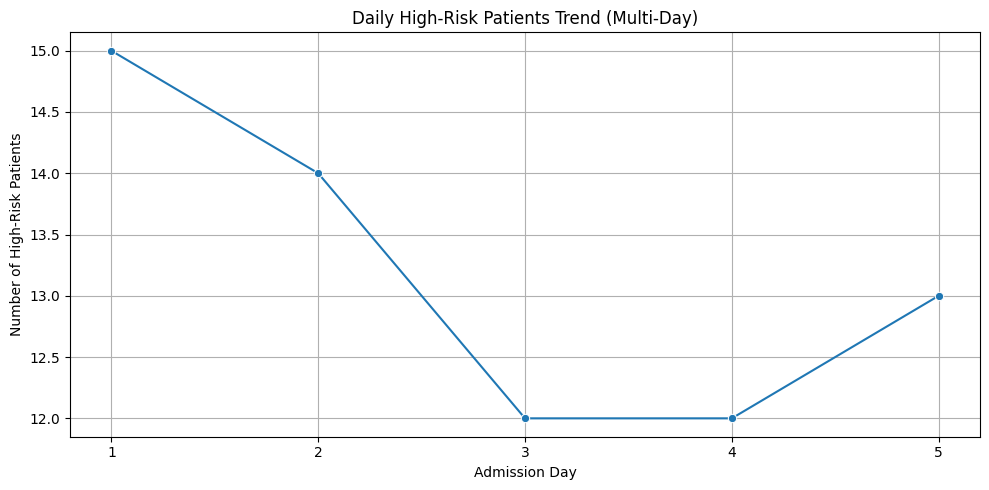

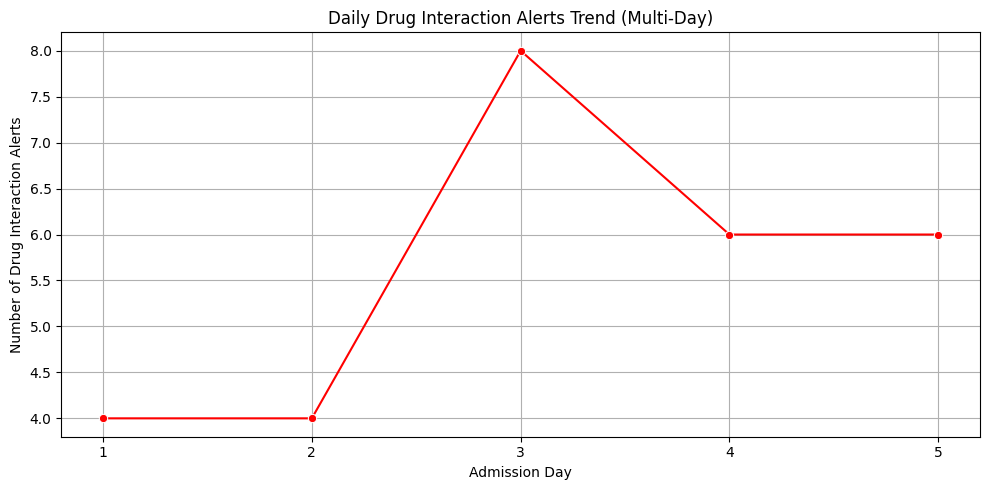

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Daily High-Risk Patients Trend
plt.figure(figsize=(10, 5))
sns.lineplot(x='admission_day', y='high_risk_count', data=daily_high_risk_multi_day, marker='o')
plt.title('Daily High-Risk Patients Trend (Multi-Day)')
plt.xlabel('Admission Day')
plt.ylabel('Number of High-Risk Patients')
plt.xticks(daily_high_risk_multi_day['admission_day'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting Daily Drug Interaction Alerts Trend
plt.figure(figsize=(10, 5))
sns.lineplot(x='admission_day', y='interaction_count', data=daily_drug_alerts_multi_day, marker='o', color='red')
plt.title('Daily Drug Interaction Alerts Trend (Multi-Day)')
plt.xlabel('Admission Day')
plt.ylabel('Number of Drug Interaction Alerts')
plt.xticks(daily_drug_alerts_multi_day['admission_day'])
plt.grid(True)
plt.tight_layout()
plt.show()

### Summary of Multi-Day Trend Analysis

- **Total Patients:** A total of 75 patients were simulated over 5 consecutive days, with 15 patients added each day.
- **High-Risk Patient Trend:** The first plot illustrates the daily count of patients identified as high-risk. This trend can highlight fluctuations in patient severity or intake patterns that might require adjusting daily clinical resources.
- **Drug Interaction Alert Trend:** The second plot shows the daily count of potential drug-drug interactions. Monitoring this trend helps identify if certain days have a higher incidence of complex medication regimens, potentially flagging the need for increased pharmacist review or altered medication prescription guidelines.
- **Implications:** Analyzing these trends helps KHCC's outpatient oncology clinic proactively manage workload, allocate resources, and identify any systemic issues contributing to higher patient risk or medication complexity on specific days.

---
### Submission Checklist

- [ ] PatientIntake class with all 4 methods working
- [ ] 15+ unique patient records with varied data
- [ ] Drug interaction table with 10+ pairs
- [ ] GroupBy analysis by diagnosis
- [ ] 3 CSV files generated (all_patients, high_risk, drug_interactions)
- [ ] Part 3 analysis (200-400 words) referencing your implementation
- [ ] Part 4 stretch challenge completed
- [ ] Pushed to GitHub with 3+ commits
- [ ] No real patient data in the notebook